In [7]:
# Proposal-faithful RQ2 artifact generator
#
# This script reads frozen Phase 3 outputs and generates only the exact
# proposal-facing RQ2 artifacts in a separate reporting layer.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid")


# Update these paths in Kaggle before running.
PHASE3_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs-phase3/thesis_outputs")
OUTPUT_ROOT = Path("/kaggle/working/thesis_outputs")

RQ = "rq2"
RQ_OUTPUT_ROOT = OUTPUT_ROOT / "results_proposal" / RQ
FIGURES_ROOT = RQ_OUTPUT_ROOT / "figures"
TABLES_ROOT = RQ_OUTPUT_ROOT / "tables"
for folder in [FIGURES_ROOT, TABLES_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

ID_COL = "TransactionID"
SOURCE_SCORE_COLUMNS = [
    "lgbm_score",
    "xgb_score",
    "full_TemporalGraphSAGE_score",
    "full_GraphSAGE_score",
]
SOURCE_DISPLAY_NAMES = [
    "LightGBM",
    "XGBoost",
    "TemporalGraphSAGE",
    "GraphSAGE",
]
ATTENTION_HEATMAP_CASES = 20


def save_table(df, name):
    df.to_csv(TABLES_ROOT / f"{name}.csv", index=False)


def save_figure(fig, name):
    fig.savefig(FIGURES_ROOT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_ROOT / f"{name}.pdf", bbox_inches="tight")
    plt.show()


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def precision_at_k(y_true, y_score, k):
    k = min(int(k), len(y_true))
    top_idx = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[top_idx]))


def recall_at_k(y_true, y_score, k):
    k = min(int(k), len(y_true))
    top_idx = np.argsort(-y_score)[:k]
    positives = max(int(np.sum(y_true)), 1)
    return float(np.sum(y_true[top_idx]) / positives)


def ndcg_at_k(y_true, y_score, k):
    k = min(int(k), len(y_true))
    top_idx = np.argsort(-y_score)[:k]
    gains = y_true[top_idx]
    discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float(np.sum(gains * discounts))

    ideal_gains = np.sort(y_true)[::-1][:k]
    ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal_gains) + 2))
    idcg = float(np.sum(ideal_gains * ideal_discounts))
    if idcg <= 0:
        return 0.0
    return dcg / idcg


def cumulative_gain_curve(y_true, y_score, num_points=100):
    order = np.argsort(-y_score)
    sorted_true = y_true[order]
    positives = max(int(np.sum(sorted_true)), 1)
    fractions = np.linspace(0.01, 1.0, num_points)
    gains = []
    for frac in fractions:
        k = max(int(len(sorted_true) * frac), 1)
        gains.append(float(np.sum(sorted_true[:k]) / positives))
    return pd.DataFrame({"PopulationFraction": fractions, "CumulativeGain": gains})

In [8]:
# Frozen inputs
PHASE3_ARTIFACTS = PHASE3_INPUT_ROOT / "artifacts" / "phase03_ranking_explainability"
ranking_predictions_df = pd.read_parquet(PHASE3_ARTIFACTS / "ranking_predictions.parquet")
ablation_df = pd.read_csv(PHASE3_ARTIFACTS / "attention_ablation_raw.csv")
attention_ranker_summary = load_json(PHASE3_ARTIFACTS / "attention_ranker_summary.json")

rank_test_df = ranking_predictions_df[ranking_predictions_df["split"] == "test"].copy().reset_index(drop=True)
y_test = rank_test_df["y_true"].astype(int).to_numpy()

In [9]:
# Table 2.1 - Ranking Efficiency
table_2_1 = pd.DataFrame(
    [
        {
            "Method": "Heuristic Score",
            "Precision@100": precision_at_k(y_test, rank_test_df["weighted_blend_score"].to_numpy(), 100),
            "Recall@100": recall_at_k(y_test, rank_test_df["weighted_blend_score"].to_numpy(), 100),
            "NDCG@100": ndcg_at_k(y_test, rank_test_df["weighted_blend_score"].to_numpy(), 100),
        },
        {
            "Method": "XGBoost Score",
            "Precision@100": precision_at_k(y_test, rank_test_df["xgb_score"].to_numpy(), 100),
            "Recall@100": recall_at_k(y_test, rank_test_df["xgb_score"].to_numpy(), 100),
            "NDCG@100": ndcg_at_k(y_test, rank_test_df["xgb_score"].to_numpy(), 100),
        },
        {
            "Method": "Learnable Ranking (Proposed)",
            "Precision@100": precision_at_k(y_test, rank_test_df["attention_ranker_score"].to_numpy(), 100),
            "Recall@100": recall_at_k(y_test, rank_test_df["attention_ranker_score"].to_numpy(), 100),
            "NDCG@100": ndcg_at_k(y_test, rank_test_df["attention_ranker_score"].to_numpy(), 100),
        },
    ]
)
save_table(table_2_1, "table_2_1_ranking_efficiency")

In [10]:
# Table 2.2 - Ablation of Ranking Components
ablation_lookup = {
    row["Configuration"]: row
    for _, row in ablation_df.iterrows()
}

selected_experiment_name = attention_ranker_summary.get("selected_experiment_name", attention_ranker_summary["experiment_name"])

table_2_2 = pd.DataFrame(
    [
        {
            "Component Removed": "Full Model",
            "AUC-PR": ablation_lookup[selected_experiment_name]["AUC-PR"],
            "Recall@100": ablation_lookup[selected_experiment_name]["Recall@100"],
        },
        {
            "Component Removed": "– Neighborhood",
            "AUC-PR": ablation_lookup["RemoveNeighborhood"]["AUC-PR"],
            "Recall@100": ablation_lookup["RemoveNeighborhood"]["Recall@100"],
        },
        {
            "Component Removed": "– Temporal",
            "AUC-PR": ablation_lookup["RemoveTemporal"]["AUC-PR"],
            "Recall@100": ablation_lookup["RemoveTemporal"]["Recall@100"],
        },
        {
            "Component Removed": "– Amount",
            "AUC-PR": ablation_lookup["RemoveAmount"]["AUC-PR"],
            "Recall@100": ablation_lookup["RemoveAmount"]["Recall@100"],
        },
    ]
)
save_table(table_2_2, "table_2_2_ranking_component_ablation")

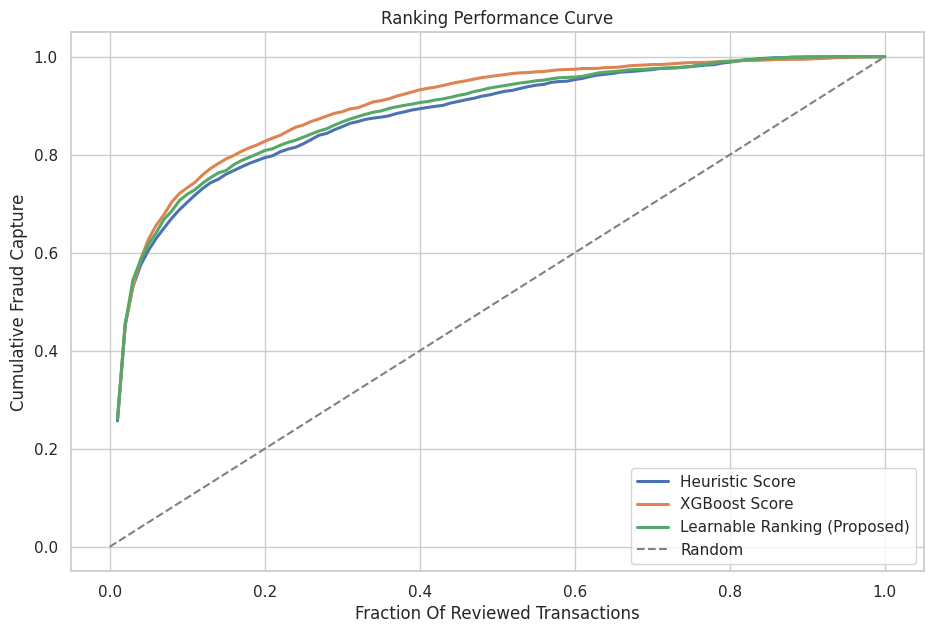

In [11]:
# Figure 2.1 - Ranking Performance Curve
curve_specs = [
    ("Heuristic Score", "weighted_blend_score"),
    ("XGBoost Score", "xgb_score"),
    ("Learnable Ranking (Proposed)", "attention_ranker_score"),
]

fig, ax = plt.subplots(figsize=(11, 7))
for model_name, score_col in curve_specs:
    curve_df = cumulative_gain_curve(y_test, rank_test_df[score_col].to_numpy())
    ax.plot(curve_df["PopulationFraction"], curve_df["CumulativeGain"], linewidth=2.2, label=model_name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random")
ax.set_title("Ranking Performance Curve")
ax.set_xlabel("Fraction Of Reviewed Transactions")
ax.set_ylabel("Cumulative Fraud Capture")
ax.legend()
save_figure(fig, "figure_2_1_ranking_performance_curve")

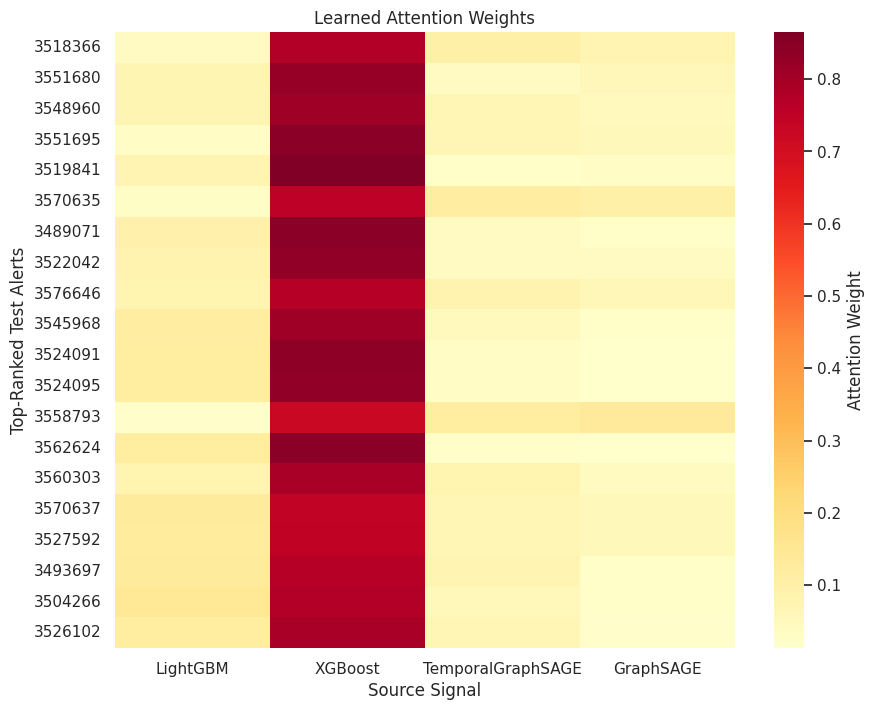

In [12]:
# Figure 2.2 - Learned Attention Weights
heatmap_df = (
    rank_test_df.sort_values("attention_ranker_score", ascending=False)
    .head(ATTENTION_HEATMAP_CASES)
    [[ID_COL] + [f"{col}_attention" for col in SOURCE_SCORE_COLUMNS]]
    .copy()
)
heatmap_matrix = heatmap_df[[f"{col}_attention" for col in SOURCE_SCORE_COLUMNS]].to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_matrix,
    cmap="YlOrRd",
    cbar_kws={"label": "Attention Weight"},
    yticklabels=[str(x) for x in heatmap_df[ID_COL].tolist()],
    xticklabels=SOURCE_DISPLAY_NAMES,
    ax=ax,
)
ax.set_title("Learned Attention Weights")
ax.set_xlabel("Source Signal")
ax.set_ylabel("Top-Ranked Test Alerts")
save_figure(fig, "figure_2_2_learned_attention_weights")